In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [3]:
df = pd.read_csv("C:\\Users\\TANISH VERMA\\OneDrive\\Desktop\\gramsevak ml\\gram_sevak_500_complaints_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 3)


,id,text,category
0,1,No water supply in ward 3 since two days,Water
1,2,Water pipe leaking near temple road,Water
2,3,Drinking water is dirty in our village,Water
3,4,Water tank is damaged near school,Water
4,5,Low water pressure in ward 5,Water


In [4]:
df["category"].value_counts()

category
Others         108
Road           106
Water          101
Electricity     94
Sanitation      91
Name: count, dtype: int64

In [5]:
X = df["text"]
y = df["category"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = model.predict(X_test_tfidf)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.96

Classification Report:

              precision    recall  f1-score   support

 Electricity       0.90      1.00      0.95        19
      Others       1.00      1.00      1.00        22
        Road       1.00      1.00      1.00        21
  Sanitation       0.94      0.94      0.94        18
       Water       0.94      0.85      0.89        20

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



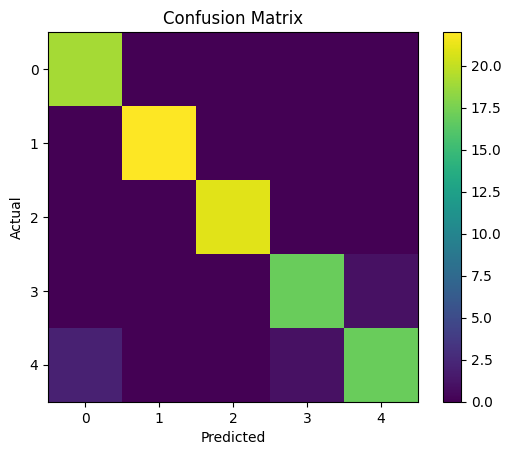

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [20]:
import joblib

joblib.dump(model, "complaint_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [21]:
def predict_complaint(text):
    text_vec = vectorizer.transform([text])
    prediction = model.predict(text_vec)
    return prediction[0]

print(predict_complaint("street light not working near temple"))
print(predict_complaint("garbage not collected in ward 3"))
print(predict_complaint("water pipe leaking near school"))

Electricity
Sanitation
Water


In [22]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.96
              precision    recall  f1-score   support

 Electricity       0.95      1.00      0.97        19
      Others       1.00      1.00      1.00        22
        Road       1.00      1.00      1.00        21
  Sanitation       0.89      0.94      0.92        18
       Water       0.94      0.85      0.89        20

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



In [23]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.96
              precision    recall  f1-score   support

 Electricity       0.90      1.00      0.95        19
      Others       1.00      1.00      1.00        22
        Road       1.00      1.00      1.00        21
  Sanitation       0.94      0.94      0.94        18
       Water       0.94      0.85      0.89        20

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



In [24]:
import joblib
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(nb_model, "naive_bayes_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']

In [25]:
loaded_model = joblib.load("logistic_regression_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

sample = ["street light not working near temple"]

sample_vec = loaded_vectorizer.transform(sample)
prediction = loaded_model.predict(sample_vec)

print(prediction)

['Electricity']
